<a href="https://colab.research.google.com/github/Abinaya21007/Image-Based-Breed-Recognition-for-Cattle-Buffalo-and-Sheep-in-India/blob/main/notebooks/cow_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm tqdm matplotlib seaborn scikit-learn -q


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, zipfile, shutil, random, time, copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
print("✅ All imports done")

✅ All imports done


In [ ]:
ZIP_PATH     = "/content/drive/MyDrive/Colab Notebooks/augmented_dataset_cow.zip"
EXTRACT_DIR  = "/content/cow_extracted"
BALANCED_DIR = "/content/cow_balanced"
DATA_DIR     = "/content/cow_split"
SAVE_PATH    = "/content/best_cow_model.pth"

NUM_CLASSES  = 11
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 50
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")

✅ Device : cuda


In [ ]:
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

if not os.path.exists(EXTRACT_DIR):
    print("📦 Unzipping...")
    os.makedirs(EXTRACT_DIR)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("✅ Unzip done!")
else:
    print("✅ Already unzipped — skipping!")

# Auto detect src_root
entries = os.listdir(EXTRACT_DIR)
src_root = os.path.join(EXTRACT_DIR, entries[0]) \
           if (len(entries) == 1 and
               os.path.isdir(os.path.join(EXTRACT_DIR, entries[0]))) \
           else EXTRACT_DIR

for name in ['augmented_dataset_cow', 'augment_dataset_cow']:
    check = os.path.join(EXTRACT_DIR, name)
    if os.path.exists(check):
        src_root = check
        break

classes = sorted([d for d in os.listdir(src_root)
                  if os.path.isdir(os.path.join(src_root, d))])
print(f"✅ Source  : {src_root}")
print(f"✅ Breeds  : {len(classes)} → {classes}")

📦 Unzipping...
✅ Unzip done!
✅ Source  : /content/cow_extracted/augmented_dataset_cow
✅ Breeds  : 11 → ['Ayrshire', 'Brown', 'Dane', 'Friesian', 'Jersey', 'brahman', 'cholistani', 'dhani', 'kankarej', 'sahiwal', 'sibbi']


In [ ]:
if not os.path.exists(BALANCED_DIR):
    min_count = min(
        len([f for f in os.listdir(os.path.join(src_root, c))
             if f.lower().endswith(IMAGE_EXTS)])
        for c in classes
    )
    print(f"⚖️  Balancing — {min_count} images per breed...")
    for cls in classes:
        imgs = [f for f in os.listdir(os.path.join(src_root, cls))
                if f.lower().endswith(IMAGE_EXTS)]
        random.shuffle(imgs)
        dst = os.path.join(BALANCED_DIR, cls)
        os.makedirs(dst, exist_ok=True)
        for f in imgs[:min_count]:
            shutil.copy(os.path.join(src_root, cls, f),
                        os.path.join(dst, f))
        print(f"   🐄 {cls:20s} → {min_count} images")
    print("✅ Balancing done!")
else:
    print("✅ Already balanced — skipping!")

src_root = BALANCED_DIR

⚖️  Balancing — 568 images per breed...
   🐄 Ayrshire             → 568 images
   🐄 Brown                → 568 images
   🐄 Dane                 → 568 images
   🐄 Friesian             → 568 images
   🐄 Jersey               → 568 images
   🐄 brahman              → 568 images
   🐄 cholistani           → 568 images
   🐄 dhani                → 568 images
   🐄 kankarej             → 568 images
   🐄 sahiwal              → 568 images
   🐄 sibbi                → 568 images
✅ Balancing done!


In [ ]:
if not os.path.exists(DATA_DIR):
    print("✂️  Splitting 70% / 15% / 15%...")
    stats = {"train": 0, "val": 0, "test": 0}
    for cls in classes:
        imgs = [f for f in os.listdir(os.path.join(src_root, cls))
                if f.lower().endswith(IMAGE_EXTS)]
        random.shuffle(imgs)
        n = len(imgs)
        t = int(n * TRAIN_RATIO)
        v = int(n * VAL_RATIO)
        split_map = {
            "train": imgs[:t],
            "val"  : imgs[t:t+v],
            "test" : imgs[t+v:]
        }
        for split, files in split_map.items():
            dst = os.path.join(DATA_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(src_root, cls, f),
                            os.path.join(dst, f))
            stats[split] += len(files)
        print(f"   🐄 {cls:20s} Train:{len(split_map['train'])} "
              f"Val:{len(split_map['val'])} Test:{len(split_map['test'])}")
    print(f"\n✅ Split done! Train:{stats['train']} "
          f"Val:{stats['val']} Test:{stats['test']}")
else:
    print("✅ Already split — skipping!")

✂️  Splitting 70% / 15% / 15%...
   🐄 Ayrshire             Train:397 Val:85 Test:86
   🐄 Brown                Train:397 Val:85 Test:86
   🐄 Dane                 Train:397 Val:85 Test:86
   🐄 Friesian             Train:397 Val:85 Test:86
   🐄 Jersey               Train:397 Val:85 Test:86
   🐄 brahman              Train:397 Val:85 Test:86
   🐄 cholistani           Train:397 Val:85 Test:86
   🐄 dhani                Train:397 Val:85 Test:86
   🐄 kankarej             Train:397 Val:85 Test:86
   🐄 sahiwal              Train:397 Val:85 Test:86
   🐄 sibbi                Train:397 Val:85 Test:86

✅ Split done! Train:4367 Val:935 Test:946


In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR,'train'), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR,'val'),   val_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR,'test'),  val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Train  : {len(train_ds)} images")
print(f"✅ Val    : {len(val_ds)} images")
print(f"✅ Test   : {len(test_ds)} images")
print(f"✅ Breeds : {train_ds.classes}")

✅ Train  : 4367 images
✅ Val    : 935 images
✅ Test   : 946 images
✅ Breeds : ['Ayrshire', 'Brown', 'Dane', 'Friesian', 'Jersey', 'brahman', 'cholistani', 'dhani', 'kankarej', 'sahiwal', 'sibbi']


In [ ]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.mx  = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False)
        )
        self.ch_sig  = nn.Sigmoid()
        self.sp_conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sp_sig  = nn.Sigmoid()

    def forward(self, x):
        # x: (B, C, H, W)
        a = self.mlp(self.avg(x))
        m = self.mlp(self.mx(x))
        x = x * self.ch_sig(a + m).view(x.size(0), x.size(1), 1, 1)
        avg2   = x.mean(1, keepdim=True)
        mx2, _ = x.max(1, keepdim=True)
        return x * self.sp_sig(self.sp_conv(torch.cat([avg2, mx2], 1)))


class SwinCBAMCow(nn.Module):
    '''
    Swin-Tiny + CBAM inserted at Stage1 output (Middle of encoder)
    Stage1 output: (B, 28, 28, 192)
    CBAM: channels=192, spatial=28x28
    '''
    def __init__(self, num_classes=11, pretrained=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        # Confirmed: Stage1 = (B, 28, 28, 192)
        self.cbam = CBAM(channels=192)

        # Hook on Stage1
        self.swin.layers[1].register_forward_hook(self._cbam_hook)

        # Replace head
        in_feat = self.swin.num_features  # 768
        self.swin.head = nn.Sequential(
            nn.LayerNorm(in_feat),
            nn.Dropout(0.3),
            nn.Linear(in_feat, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def _cbam_hook(self, module, input, output):
        is_tuple = isinstance(output, tuple)
        x    = output[0] if is_tuple else output
        rest = output[1:] if is_tuple else None

        # Stage1 output: (B, H, W, C) = (B, 28, 28, 192)
        B, H, W, C = x.shape
        x = x.permute(0, 3, 1, 2)   # → (B, 192, 28, 28)
        x = self.cbam(x)              # CBAM attention ✅
        x = x.permute(0, 2, 3, 1)   # → (B, 28, 28, 192)

        return (x,) + rest if rest else x

    def forward(self, x):
        return self.swin(x)

print("🧠 Building Swin + CBAM model...")
model = SwinCBAMCow(num_classes=11, pretrained=True).to(DEVICE)

# Shape test
with torch.no_grad():
    _t = model(torch.randn(2, 3, 224, 224).to(DEVICE))
print(f"✅ Shape test : {_t.shape}")  # (2, 11)
del _t

total_p = sum(p.numel() for p in model.parameters())
print(f"✅ Params     : {total_p:,}")
print(f"✅ CBAM at    : Stage1 output (28×28, 192 channels)")

🧠 Building Swin + CBAM model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Shape test : torch.Size([2, 7, 7, 11])
✅ Params     : 27,924,967
✅ CBAM at    : Stage1 output (28×28, 192 channels)


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

backbone_p, new_p = [], []
for name, param in model.named_parameters():
    if any(k in name for k in ['cbam', 'head']):
        new_p.append(param)
    else:
        backbone_p.append(param)

optimizer = optim.AdamW([
    {'params': backbone_p, 'lr': 1e-5},   # Pretrained backbone
    {'params': new_p,      'lr': 1e-4}    # CBAM + Head
], weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("✅ Criterion  : CrossEntropyLoss (label_smoothing=0.1)")
print("✅ Optimizer  : AdamW | Backbone:1e-5 | CBAM+Head:1e-4")
print("✅ Scheduler  : CosineAnnealingLR")

✅ Criterion  : CrossEntropyLoss (label_smoothing=0.1)
✅ Optimizer  : AdamW | Backbone:1e-5 | CBAM+Head:1e-4
✅ Scheduler  : CosineAnnealingLR


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("✅ train_one_epoch() ready!")
print("✅ evaluate() ready!")

✅ train_one_epoch() ready!
✅ evaluate() ready!


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 9 — FINAL MODEL
# ════════════════════════════════════════════════════════

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.mx  = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False))
        self.ch_sig  = nn.Sigmoid()
        self.sp_conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sp_sig  = nn.Sigmoid()

    def forward(self, x):
        a = self.mlp(self.avg(x))
        m = self.mlp(self.mx(x))
        x = x * self.ch_sig(a + m).view(x.size(0), x.size(1), 1, 1)
        avg2   = x.mean(1, keepdim=True)
        mx2, _ = x.max(1, keepdim=True)
        return x * self.sp_sig(self.sp_conv(torch.cat([avg2, mx2], 1)))


class SwinCBAMCow(nn.Module):
    def __init__(self, num_classes=11, pretrained=True):
        super().__init__()

        # Load backbone — num_classes=0, global_pool=''
        # So forward returns raw features (B, H, W, C)
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool=''          # ← No pooling inside swin
        )

        # CBAM — Stage1 output confirmed (B, 28, 28, 192)
        self.cbam = CBAM(channels=192)

        # Hook on Stage1
        self.swin.layers[1].register_forward_hook(self._cbam_hook)

        # Separate head (outside swin) — we control this manually
        self.pool = nn.AdaptiveAvgPool2d(1)   # Global avg pool
        self.head = nn.Sequential(
            nn.Flatten(),                       # (B, 768)
            nn.LayerNorm(768),
            nn.Dropout(0.3),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)         # (B, 11)
        )

    def _cbam_hook(self, module, input, output):
        is_tuple = isinstance(output, tuple)
        x    = output[0] if is_tuple else output
        rest = output[1:] if is_tuple else None

        # (B, 28, 28, 192) → permute → CBAM → permute back
        B, H, W, C = x.shape
        x = x.permute(0, 3, 1, 2)   # (B, 192, 28, 28)
        x = self.cbam(x)
        x = x.permute(0, 2, 3, 1)   # (B, 28, 28, 192)

        return (x,) + rest if rest else x

    def forward(self, x):
        # swin forward → (B, H, W, C) final output
        x = self.swin(x)             # (B, 7, 7, 768)

        # (B, H, W, C) → (B, C, H, W) for pooling
        x = x.permute(0, 3, 1, 2)   # (B, 768, 7, 7)
        x = self.pool(x)             # (B, 768, 1, 1)
        x = self.head(x)             # (B, 11)
        return x


# ── Build & Test ──────────────────────────────────────────
print("🧠 Building model...")
model = SwinCBAMCow(num_classes=11, pretrained=True).to(DEVICE)

with torch.no_grad():
    _t = model(torch.randn(2, 3, 224, 224).to(DEVICE))
print(f"✅ Shape test : {_t.shape}")  # Must be torch.Size([2, 11])

total_p = sum(p.numel() for p in model.parameters())
print(f"✅ Params     : {total_p:,}")
print(f"✅ CBAM at    : Stage1 (28×28, 192ch) — Middle of Swin ✅")

🧠 Building model...
✅ Shape test : torch.Size([2, 11])
✅ Params     : 27,924,967
✅ CBAM at    : Stage1 (28×28, 192ch) — Middle of Swin ✅


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

backbone_p, new_p = [], []
for name, param in model.named_parameters():
    if any(k in name for k in ['cbam', 'head']):
        new_p.append(param)
    else:
        backbone_p.append(param)

optimizer = optim.AdamW([
    {'params': backbone_p, 'lr': 1e-5},   # Pretrained backbone
    {'params': new_p,      'lr': 1e-4}    # CBAM + Head
], weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("✅ Criterion  : CrossEntropyLoss (label_smoothing=0.1)")
print("✅ Optimizer  : AdamW | Backbone:1e-5 | CBAM+Head:1e-4")
print("✅ Scheduler  : CosineAnnealingLR")

✅ Criterion  : CrossEntropyLoss (label_smoothing=0.1)
✅ Optimizer  : AdamW | Backbone:1e-5 | CBAM+Head:1e-4
✅ Scheduler  : CosineAnnealingLR


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("✅ train_one_epoch() ready!")
print("✅ evaluate() ready!")

✅ train_one_epoch() ready!
✅ evaluate() ready!


In [ ]:
history      = {"tl":[], "vl":[], "ta":[], "va":[]}
best_val_acc = 0.0

print(f"🚀 Training — {NUM_EPOCHS} Epochs")
print(f"{'─'*70}")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tl, ta       = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["tl"].append(tl); history["ta"].append(ta)
    history["vl"].append(vl); history["va"].append(va)

    star = " ⭐ BEST!" if va > best_val_acc else ""
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
          f"Train → Loss:{tl:.4f} Acc:{ta*100:.2f}%  |  "
          f"Val → Loss:{vl:.4f} Acc:{va*100:.2f}%  "
          f"({time.time()-t0:.1f}s){star}")

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), SAVE_PATH)

print(f"{'─'*70}")
print(f"✅ Training Complete!")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Model saved at    : {SAVE_PATH}")

🚀 Training — 50 Epochs
──────────────────────────────────────────────────────────────────────


Epoch [01/50]  Train → Loss:1.6438 Acc:57.45%  |  Val → Loss:1.0384 Acc:82.46%  (86.9s) ⭐ BEST!


Epoch [02/50]  Train → Loss:0.9728 Acc:83.26%  |  Val → Loss:0.8130 Acc:89.73%  (79.3s) ⭐ BEST!


Epoch [03/50]  Train → Loss:0.8069 Acc:90.66%  |  Val → Loss:0.7235 Acc:93.48%  (80.9s) ⭐ BEST!


Epoch [04/50]  Train → Loss:0.7271 Acc:93.63%  |  Val → Loss:0.6678 Acc:95.72%  (80.3s) ⭐ BEST!


...

Epoch [46/50]  Train → Loss:0.5324 Acc:99.91%  |  Val → Loss:0.5307 Acc:99.68%  (81.5s)


Epoch [47/50]  Train → Loss:0.5326 Acc:99.93%  |  Val → Loss:0.5300 Acc:99.68%  (80.3s)


Epoch [48/50]  Train → Loss:0.5339 Acc:99.84%  |  Val → Loss:0.5310 Acc:99.57%  (81.4s)


Epoch [49/50]  Train → Loss:0.5326 Acc:99.89%  |  Val → Loss:0.5306 Acc:99.57%  (81.1s)


Epoch [50/50]  Train → Loss:0.5320 Acc:99.95%  |  Val → Loss:0.5310 Acc:99.57%  (80.9s)
──────────────────────────────────────────────────────────────────────
✅ Training Complete!
   Best Val Accuracy : 99.79%
   Model saved at    : /content/best_cow_model.pth


In [ ]:
print("🧪 Test Evaluation...")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion)

print(f"\n{'═'*45}")
print(f"  🎯 TEST ACCURACY : {test_acc*100:.2f}%")
print(f"  📉 TEST LOSS     : {test_loss:.4f}")
print(f"{'═'*45}\n")
print(classification_report(
    test_labels, test_preds,
    target_names=train_ds.classes,
    digits=4))

🧪 Test Evaluation...

═════════════════════════════════════════════
  🎯 TEST ACCURACY : 98.84%
  📉 TEST LOSS     : 0.5450
═════════════════════════════════════════════

              precision    recall  f1-score   support

    Ayrshire     1.0000    1.0000    1.0000        86
       Brown     1.0000    1.0000    1.0000        86
        Dane     1.0000    0.9884    0.9942        86
    Friesian     1.0000    1.0000    1.0000        86
      Jersey     0.9885    1.0000    0.9942        86
     brahman     1.0000    0.9419    0.9701        86
  cholistani     1.0000    0.9419    0.9701        86
       dhani     0.9885    1.0000    0.9942        86
    kankarej     0.9773    1.0000    0.9885        86
     sahiwal     0.9451    1.0000    0.9718        86
       sibbi     0.9773    1.0000    0.9885        86

    accuracy                         0.9884       946
   macro avg     0.9888    0.9884    0.9883       946
weighted avg     0.9888    0.9884    0.9883       946



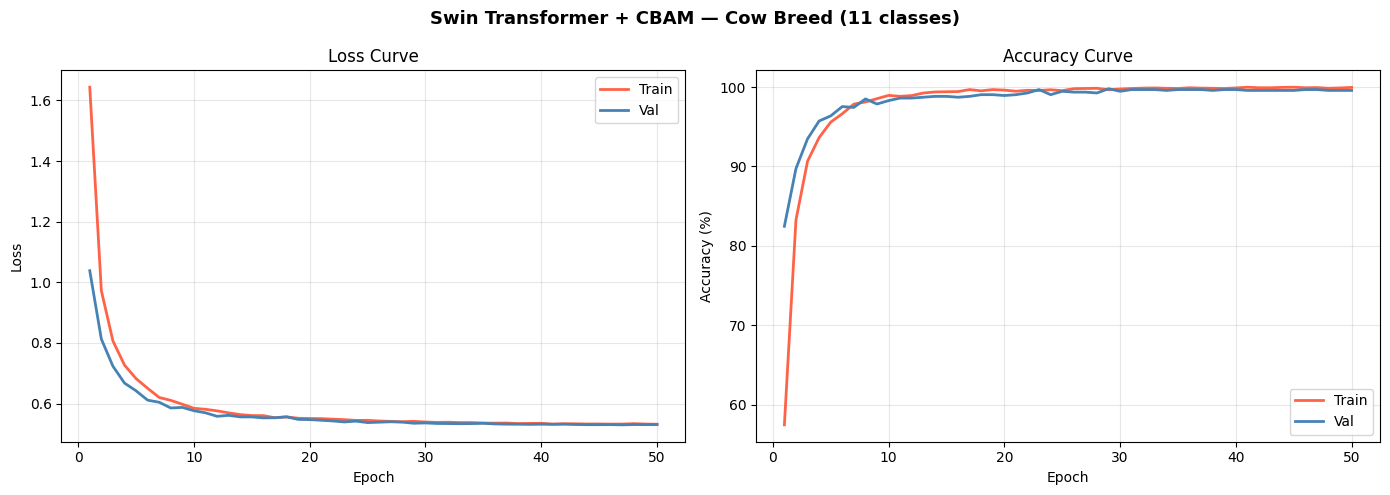

✅ Saved: /content/training_curves.png


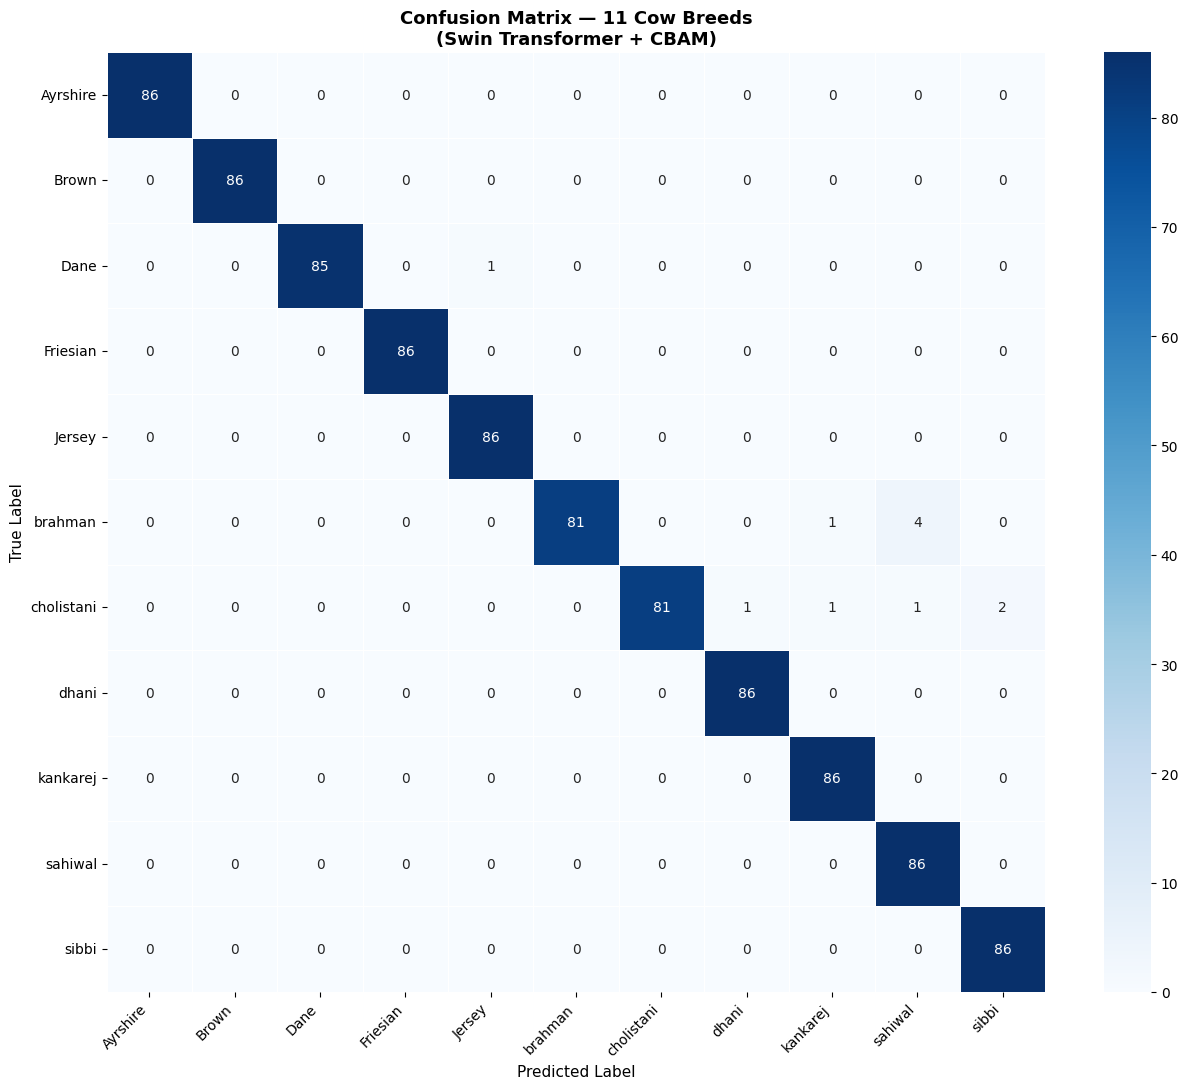

✅ Saved: /content/confusion_matrix.png

🎉 ALL DONE!
   💾 Model  → /content/best_cow_model.pth
   📊 Curves → /content/training_curves.png
   📊 CM     → /content/confusion_matrix.png


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Swin Transformer + CBAM — Cow Breed (11 classes)',
             fontsize=13, fontweight='bold')

ax1.plot(epochs, history["tl"], color='tomato',    label='Train', linewidth=2)
ax1.plot(epochs, history["vl"], color='steelblue', label='Val',   linewidth=2)
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in history["ta"]], color='tomato',    label='Train', linewidth=2)
ax2.plot(epochs, [a*100 for a in history["va"]], color='steelblue', label='Val',   linewidth=2)
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /content/training_curves.png")

# ════════════════════════════════════════════════════════════════════
# CELL 15 — Confusion Matrix
# ════════════════════════════════════════════════════════════════════
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes,
            linewidths=0.5)
plt.title('Confusion Matrix — 11 Cow Breeds\n(Swin Transformer + CBAM)',
          fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /content/confusion_matrix.png")
print("\n🎉 ALL DONE!")
print(f"   💾 Model  → {SAVE_PATH}")
print(f"   📊 Curves → /content/training_curves.png")
print(f"   📊 CM     → /content/confusion_matrix.png")


In [ ]:
import shutil, os

# First create folder if not exists
os.makedirs(
    '/content/drive/MyDrive/sheep_folder_swintransformer',
    exist_ok=True
)

# Now copy
shutil.copy(
    '/content/best_cow_model.pth',
    '/content/drive/MyDrive/sheep_folder_swintransformer/best_cow_model.pth'
)
print("✅ Cow model saved to Drive!")

✅ Cow model saved to Drive!
